## IIP314W Optimización aplicada a negocios

Optimización con restricciones, multiplicadores de Lagrange.

### Optimización con restricción de no negatividad

Regularmente en la resolución de problemas, no podemos contar con tiempos, cantidades, precios u otra variable negativa. Como primera dificultad, pensaremos en los problemas de la clase enterior, pero agregandole esta restricción y tenemos dos casos.

a. En el caso que el punto crítico, ya cumpla con la condición de no negatividad, esta condición no tendrá ninguna relevancia.

b. Si el punto crítico, queda fuera del cuadrante positivo, debemos considerar esta restricción, ahora veremos como.

### Optimización con restricción de igualdad.

En este caso, en calculo diferencial, se debe haber visto multiplicadores de Lagrange, esto se aplica a los problemas de este tipo.

$$ Min \space f(\vec{x}) $$

Sujeto a, $ g_i(\vec{x}) = c$, donde existen i restricciones de igualdad.

Para el problema anterior, si la función es continua y derivable, en el caso b nuestro punto critico, necesariamente estará en el limite es decir tenemos tres opciones:

a. $x = 0$

b. $y = 0$

c. $x = 0$, e $y = 0$

Y estos tres casos corresponden a problemas de optimización con restricciones de igualdad. Entonces es un subconjunto de problemas con restricciones de igualdad. Repasemos como funcionan los **multiplicadores de Lagrange**.

En su casa, puede revisar la siguiente lista con ejemplos, tenga cuidado con el orden de reproducción de los videos:

https://www.youtube.com/watch?v=gM1ZCuPDP_A&list=PLXyzsILZs43DtCxucLO1cd-hO3kcMsgxP

#### Ejercicio 1. Notebooks Trigo

El profesor acaba de instalar una fábrica ensambladora de un tipo de notebook en Chile. Para venderlos, debe realizar publicidad en los medios de comunicación. Sea $x$ el número de computadores vendidos e $y$ el gasto en publicidad, suponga que la función de ingresos en millones de pesos es la siguiente y usted desea maximizar sus ingresos.

$$ Máx \left( 48x + 96 y - x^2 - 2xy - 9y^2 \right) $$

Como el profesor no es millonario, tiene un presupuesto máximo que quiere gastar completamente para promocionar su producto, esta restricción es la siguiente:

$$ 5x + y = 54 $$

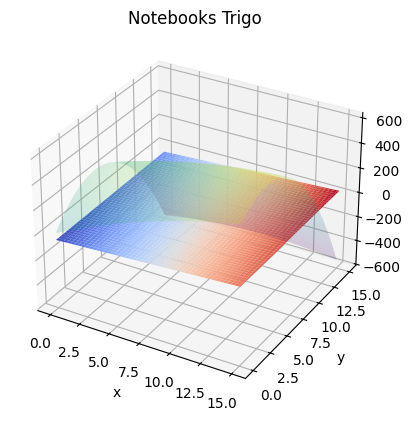

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Funcion objetivo
def fobj(x, y):
    return 48*x + 96*y - x**2 - 2*x*y - 9*y**2

def g(x, y):
    return 5*x + y - 54

# Crear un rango de valores para x y y
x = np.linspace(0, 15, 100)  # 100 puntos entre -20 y 20
y = np.linspace(0, 15, 100)  # 100 puntos entre -20 y 20

# Crear una malla de puntos (x, y)
X, Y = np.meshgrid(x, y)

# Calcular los valores de la función para cada punto de la malla
Z = fobj(X, Y)

Zr = g(X, Y)

# from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.2)
ax.plot_surface(X, Y, Zr, cmap='coolwarm')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.title('Notebooks Trigo')
plt.show()

- Resolvamos:

$$ L(x,y,\lambda) = 48x + 96y - x^2 - 2xy - 9y^2 + \lambda (5x + y - 54) $$

$$ \frac{\partial L}{\partial x} : \space 48 - 2x - 2y + 5 \lambda = 0 $$

$$ \frac{\partial L}{\partial y} : \space 96 - 2x - 18y + \lambda = 0 $$

Más la restricción, o derivada parcial con respecto a $\lambda$.
$$ \frac{\partial L}{\partial \lambda} : \space 5x + y - 54 = 0 $$

Despejando lambda en la ecuación de la derivada parcial respecto a y, luego reemplazando en la ecuacion de la derivada parcial de x.

$$ 48 - 2x -2y - 5 (96 - 2x - 18y) = 0 $$

Reduciendo terminos,

$$ x + 11y - 54 = 0 $$

Despejando x en la ecuación anterior y reemplazando en la restricción,

$$ 5 (54 - 11y) + y - 54 = 0 $$

Solución (punto crítico)

$$ y^* = 4 , \quad x^* = 10 , \quad \lambda^* = -4 $$

$$ f(10, 4) = 540$$

Discutir si es máximo o minimo, ¿tendrá que ver el signo de $\lambda^*$?.

Veamos si podemos encontrar computacionalmente los puntos criticos.

In [2]:
from scipy.optimize import minimize
import numpy as np

def funcion_objetivo(x):
    return -48*x[0]-96*x[1]+x[0]**2+2*x[0]*x[1]+9*x[1]**2

def restriccion(x):
  return 5*x[0] + x[1] - 54

# si hay mas restricciones se agregan a la lista
rest_list = [{'type': 'eq', 'fun': restriccion}]

# las nunca bien ponderadas restricciones de no negatividad
noneg = [(0, np.inf), (0, np.inf)]

solucion_inicial = np.array([0, 0])

# Minimize the function using the Nelder-Mead method
result = minimize(funcion_objetivo, solucion_inicial, method='SLSQP', bounds=noneg, constraints=rest_list)

# Print the result
print(result)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -540.0000000000001
       x: [ 1.000e+01  4.000e+00]
     nit: 5
     jac: [-2.000e+01 -4.000e+00]
    nfev: 16
    njev: 5


Misma solución... o casi casi. Resuelva los siguientes ejercicios, analiticamente y comprueba con scipy.minimize.

#### Ejercicio 2.

Un pentágono se forma al colocar un triángulo isósceles sobre un rectángulo, como se muestra en el diagrama. Si el perímetro del pentágono es 10 metros, halle las longitudes de los lados del pentágono que maximizarán el área del pentágono.

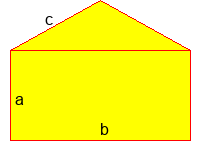

In [62]:
import PIL.Image as img
import PIL.ImageFont as fnt
import PIL.ImageDraw as drw

w, h = 200, 150
rect_points = [(10, 50), (w - 10, h - 10)]
triang_points = [(10, 50), (w - 10, 50), (w/2, 0)]

# creating new Image object
e2 = img.new("RGB", (w, h), (255,255,255))

# dib es la imagen donde voy a dibujar
dib = drw.Draw(e2)
f = fnt.truetype("arial.ttf", 16)
dib.polygon(triang_points, fill="yellow", outline ="red")
dib.rectangle(rect_points, fill="yellow", outline ="red")
dib.text((15,90), "a", (0,0,0), font=f)
dib.text((100,120), "b", (0,0,0), font=f)
dib.text((45,10), "c", (0,0,0), font=f)
e2

#### Ejercicio 3.

Halle las distancias mínima y máxima entre la elipse $x^2+xy+2y^2=1$ y el origen.

#### Ejercicio 4.

Un gran contenedor con forma de sólido rectangular debe tener un volumen de $480 m^3$. La construcción del fondo del contenedor cuesta $5.000$ pesos por metro cuadrado, mientras que la parte superior y los laterales cuestan $3.000$ pesos por metro cuadrado. Utilice los multiplicadores de Lagrange para calcular las dimensiones del contenedor de este tamaño que tenga el mínimo costo.